# ⚙️ Data Preprocessing + Feature Engineering
## Customer Churn Prediction Project
**Aim** Raw data → ML-ready + reusable sklearn Pipeline

In [ ]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
import pickle
import sys
import warnings
warnings.filterwarnings('ignore')

# src module import
sys.path.append('..')
from src.feature_engineering import clean_data, engineer_features

print("✅ Libraries loaded!")

✅ Libraries loaded!


In [2]:
# Data Load
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f"Original shape: {df.shape}")
df.head(3)

Original shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


Step 1: Data Cleaning

In [ ]:
# Clean data (src থেকে function use)
df_clean = clean_data(df)

print("✅ Cleaning done!")
print(f"Shape after cleaning : {df_clean.shape}")
print(f"Missing values left  : {df_clean.isnull().sum().sum()}")
print(f"\nTarget distribution  :")
print(df_clean['Churn'].value_counts())
print(f"\nChurn rate: {df_clean['Churn'].mean()*100:.1f}%")
df_clean.head(3)

✅ Cleaning done!
Shape after cleaning : (7043, 20)
Missing values left  : 0

Target distribution  :
Churn
0    5174
1    1869
Name: count, dtype: int64

Churn rate: 26.5%


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,1,0,1,0,0,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,Male,0,0,0,34,1,0,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,0
2,Male,0,0,0,2,1,0,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1


Step 2: Feature Engineering

In [ ]:
# Feature engineering
df_featured = engineer_features(df_clean)

new_features = [
    'AvgMonthlySpend', 'ChargeIncreaseRate', 'TotalServices',
    'IsLongTermCustomer', 'IsNewCustomer',
    'IsHighValue', 'ContractRiskScore'
]

print("✅ Feature Engineering done!")
print(f"\ncreate new 7 features :")
print(df_featured[new_features].describe().round(2))

✅ Feature Engineering done!

7টা নতুন features তৈরি হয়েছে:
       AvgMonthlySpend  ChargeIncreaseRate  TotalServices  IsLongTermCustomer  \
count          7043.00             7043.00        7043.00             7043.00   
mean             64.76               -0.00           3.36                0.56   
std              30.19                2.61           2.06                0.50   
min              13.78              -18.90           0.00                0.00   
25%              35.94               -1.16           1.00                0.00   
50%              70.34                0.00           3.00                1.00   
75%              90.17                1.15           5.00                1.00   
max             121.40               19.13           8.00                1.00   

       IsNewCustomer  IsHighValue  ContractRiskScore  
count        7043.00      7043.00            7043.00  
mean            0.21         0.51               2.31  
std             0.41         0.50            

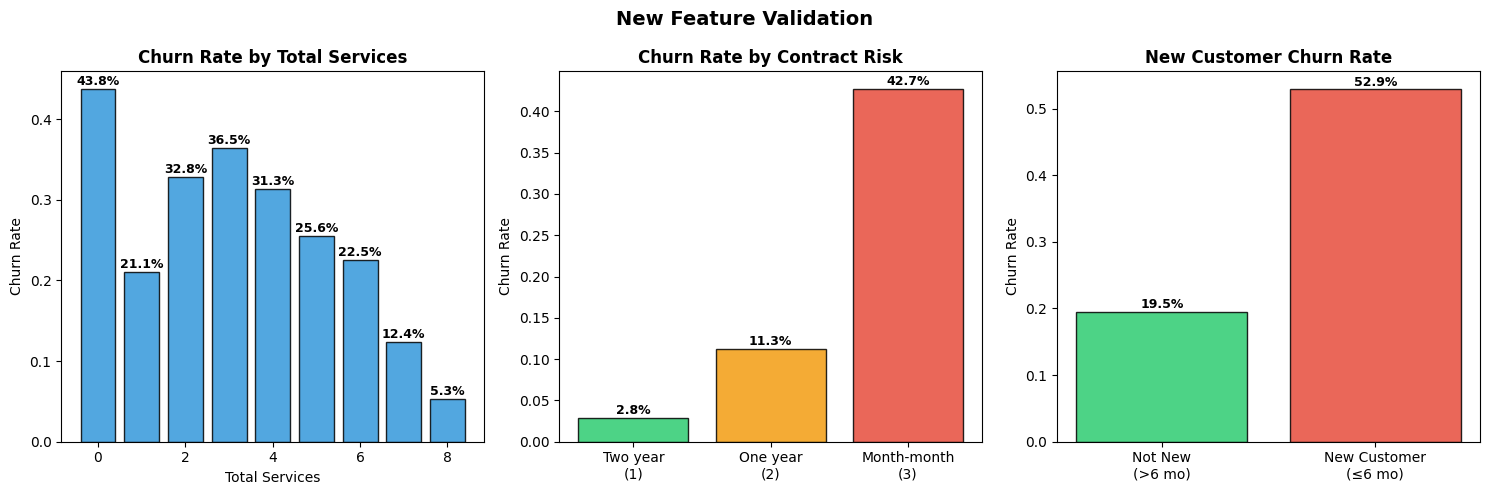

In [ ]:
# new feature validation
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# TotalServices vs Churn
ts_churn = df_featured.groupby('TotalServices')['Churn'].mean()
axes[0].bar(ts_churn.index, ts_churn.values,
            color='#3498db', edgecolor='black', alpha=0.85)
axes[0].set_title('Churn Rate by Total Services',
                  fontweight='bold')
axes[0].set_xlabel('Total Services')
axes[0].set_ylabel('Churn Rate')

# ContractRiskScore vs Churn
cr_churn = df_featured.groupby('ContractRiskScore')['Churn'].mean()
axes[1].bar(
    ['Two year\n(1)', 'One year\n(2)', 'Month-month\n(3)'],
    cr_churn.values,
    color=['#2ecc71', '#f39c12', '#e74c3c'],
    edgecolor='black', alpha=0.85
)
axes[1].set_title('Churn Rate by Contract Risk',
                  fontweight='bold')
axes[1].set_ylabel('Churn Rate')

# IsNewCustomer vs Churn
nc_churn = df_featured.groupby('IsNewCustomer')['Churn'].mean()
axes[2].bar(
    ['Not New\n(>6 mo)', 'New Customer\n(≤6 mo)'],
    nc_churn.values,
    color=['#2ecc71', '#e74c3c'],
    edgecolor='black', alpha=0.85
)
axes[2].set_title('New Customer Churn Rate',
                  fontweight='bold')
axes[2].set_ylabel('Churn Rate')

for ax in axes:
    for bar in ax.patches:
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{bar.get_height():.1%}',
            ha='center', fontsize=9, fontweight='bold'
        )

plt.suptitle('New Feature Validation',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/results/feature_validation.png',
            dpi=150, bbox_inches='tight')
plt.show()

 Step 3: Sklearn Pipeline

In [ ]:
# Columns devide
numerical_features = [
    'tenure', 'MonthlyCharges', 'TotalCharges',
    'AvgMonthlySpend', 'ChargeIncreaseRate',
    'TotalServices', 'ContractRiskScore'
]

categorical_features = [
    'InternetService', 'Contract', 'PaymentMethod'
]

binary_features = [
    'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'PaperlessBilling',
    'IsLongTermCustomer', 'IsNewCustomer', 'IsHighValue'
]

print(f"Numerical   : {len(numerical_features)} features")
print(f"Categorical : {len(categorical_features)} features")
print(f"Binary      : {len(binary_features)} features")
print(f"Total       : {len(numerical_features)+len(categorical_features)+len(binary_features)} features")

Numerical   : 7 features
Categorical : 3 features
Binary      : 15 features
Total       : 25 features


In [7]:
# ColumnTransformer Pipeline
numerical_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('encoder', OneHotEncoder(
        drop='first',
        sparse_output=False,
        handle_unknown='ignore'
    ))
])

preprocessor = ColumnTransformer([
    ('num', numerical_pipeline,   numerical_features),
    ('cat', categorical_pipeline, categorical_features),
    ('bin', 'passthrough',        binary_features)
])

print("✅ Preprocessor pipeline ready!")

✅ Preprocessor pipeline ready!


In [8]:
# Train-Test Split
all_features = numerical_features + categorical_features + binary_features
X = df_featured[all_features]
y = df_featured['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train set : {X_train.shape}")
print(f"Test set  : {X_test.shape}")
print(f"\nTrain churn rate: {y_train.mean():.3f}")
print(f"Test  churn rate: {y_test.mean():.3f}")
print("✅ Stratified split — rates same!")

Train set : (5634, 25)
Test set  : (1409, 25)

Train churn rate: 0.265
Test  churn rate: 0.265
✅ Stratified split — rates same!


In [9]:
# Fit & Transform
# ⚠️ শুধু train data তে fit করো — data leakage prevent করতে
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

# Feature names
cat_names = (preprocessor
             .named_transformers_['cat']
             .named_steps['encoder']
             .get_feature_names_out(categorical_features))

all_feature_names = (numerical_features +
                     list(cat_names) +
                     binary_features)

print(f"Processed train : {X_train_processed.shape}")
print(f"Processed test  : {X_test_processed.shape}")
print(f"Total features  : {len(all_feature_names)}")

Processed train : (5634, 29)
Processed test  : (1409, 29)
Total features  : 29


In [ ]:
# save everything
import os
os.makedirs('../models', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

# Preprocessor
with open('../models/preprocessor.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)

# Processed arrays
np.save('../data/processed/X_train_processed.npy', X_train_processed)
np.save('../data/processed/X_test_processed.npy',  X_test_processed)
np.save('../data/processed/y_train.npy', y_train.values)
np.save('../data/processed/y_test.npy',  y_test.values)

# Feature names
with open('../models/feature_names.pkl', 'wb') as f:
    pickle.dump(all_feature_names, f)

# Original splits
X_train.to_csv('../data/processed/X_train.csv', index=False)
X_test.to_csv('../data/processed/X_test.csv',   index=False)
y_train.to_csv('../data/processed/y_train.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv',   index=False)

# Featured dataset
df_featured.to_csv('../data/processed/cleaned_featured_data.csv',
                   index=False)

print("✅ saved all preprocessed files!")
print("\n📁 Saved:")
print("  models/preprocessor.pkl")
print("  models/feature_names.pkl")
print("  data/processed/ → arrays + CSVs")

✅ সব files save হয়েছে!

📁 Saved:
  models/preprocessor.pkl
  models/feature_names.pkl
  data/processed/ → arrays + CSVs

➡️  Next: 03_modeling.ipynb
